<a id="0"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:200%;text-align:center;border:5px solid #ffffff;border-radius:10px 80px;padding:20px;box-shadow: 10px 10px 5px #eeeeee;">🌾 Crop Recommendation System: A Machine Learning Approach</p>


---

### **1. Introduction**
Precision agriculture is the future of farming. By leveraging data-driven insights, farmers can optimize their yield and reduce resource waste. This project aims to build a robust **Multi-Class Classification** model that recommends the most suitable crop to grow based on specific environmental and soil conditions.

### **2. Dataset Overview**
The dataset contains **22 different crops** and considers **7 key features**:
*   **Soil Nutrients:** Nitrogen (N), Phosphorous (P), and Potassium (K) content.
*   **Climate Conditions:** Temperature, Relative Humidity, and Rainfall.
*   **Soil Chemistry:** pH value.

### **3. Project Goals**
*   **EDA:** Perform Exploratory Data Analysis to understand the relationship between soil chemistry and crop types.
*   **Modeling:** Implement and compare multiple Machine Learning algorithms: **Logistic Regression**, **Decision Trees**, and **Random Forest**.
*   **Deployment:** Export the final model using **Pickle** for real-world application.

### **4. Results Summary**
In this notebook, we achieved a peak testing accuracy of **99.36%** using the **Random Forest** algorithm, demonstrating high reliability and minimal overfitting.

---


 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Exploring Data</p>

In [1]:
import pandas as pd 
import numpy as np

In [2]:
data = pd.read_csv(r"Crop_recommendation.csv")

data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
types = list(data['label'].unique())

for i in types:
    print(i)

rice
maize
chickpea
kidneybeans
pigeonpeas
mothbeans
mungbean
blackgram
lentil
pomegranate
banana
mango
grapes
watermelon
muskmelon
apple
orange
papaya
coconut
cotton
jute
coffee


In [5]:
len(types)

22

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Preprocessing Data</p>

In [6]:
data.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['label'] = le.fit_transform(data['label'])

crop_id = dict(zip(le.classes_, range(len(le.classes_))))

print(crop_id)

{'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5, 'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11, 'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16, 'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21}


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   int32  
dtypes: float64(4), int32(1), int64(3)
memory usage: 129.0 KB


In [9]:
x = data.drop(columns=['label'])

y = data['label']

### The Data Is **Preprocessed**

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">LogisticRegression</p>

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)

lr_model = LogisticRegression(max_iter=9500)

lr_model.fit(x_train, y_train)

LogisticRegression(max_iter=9500)

<div style="background-color:#44d180; color:#0a0a0b; font-family:roboto; font-size:100%; text-align:left; border-radius:10px; padding:10px; border-left: 10px solid #2e8b57; width: 50%;">
    <strong>Note:</strong> Warning here because <strong>LogisticRegression</strong> want to scale features or increase max_iter.
</div>


In [12]:
train_acc = lr_model.score(x_train, y_train)
test_acc = lr_model.score(x_test, y_test)
y_pred = lr_model.predict(x_test)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(classification_report(y_test, y_pred))
print(f"Training Score: {train_acc:.2%}")
print(f"Testing Score: {test_acc:.2%}")
print(f"Precision Score: {precision:.2%}")
print(f"Recall Score: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.87      0.87      0.87        23
           9       1.00      0.95      0.97        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       0.96      0.96      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       0.96    

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">DecisionTree</p>

In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state= 42 )

dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
train_acc = dt_model.score(x_train, y_train)
test_acc = dt_model.score(x_test, y_test)
y_pred = dt_model.predict(x_test)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(classification_report(y_test, y_pred))
print(f"Training Score: {train_acc:.2%}")
print(f"Testing Score: {test_acc:.2%}")
print(f"Precision Score: {precision:.2%}")
print(f"Recall Score: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      0.96      0.94        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Validation Score (DT)</p>

In [15]:
from sklearn.model_selection import cross_val_score

cross_score = cross_val_score(dt_model, x, y, cv = 10)

print(f"Score For Ten Turns: {cross_score}")

print(f"Score Mean: {cross_score.mean():.2%}")

Score For Ten Turns: [0.98636364 0.98636364 0.99545455 0.99090909 0.99090909 0.99090909
 0.99545455 0.99090909 0.98181818 0.99545455]
Score Mean: 99.05%


 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">RandomForest</p>

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state= 42)

rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
train_acc = rf_model.score(x_train, y_train)
test_acc = rf_model.score(x_test, y_test)
y_pred = rf_model.predict(x_test)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(classification_report(y_test, y_pred))
print(f"Training Score: {train_acc:.2%}")
print(f"Testing Score: {test_acc:.2%}")
print(f"Precision Score: {precision:.2%}")
print(f"Recall Score: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Validation Score(RF)</p>

In [18]:
cross_score = cross_val_score(rf_model, x, y, cv = 10)

print(f"Score Validation For Ten Turns: {cross_score}")

print(f"Score Mean: {cross_score.mean():.2%}")

Score Validation For Ten Turns: [0.99545455 0.99545455 1.         0.99090909 0.99545455 0.99545455
 0.99545455 0.99545455 0.97727273 0.99545455]
Score Mean: 99.36%


 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Data Interpretability</p>

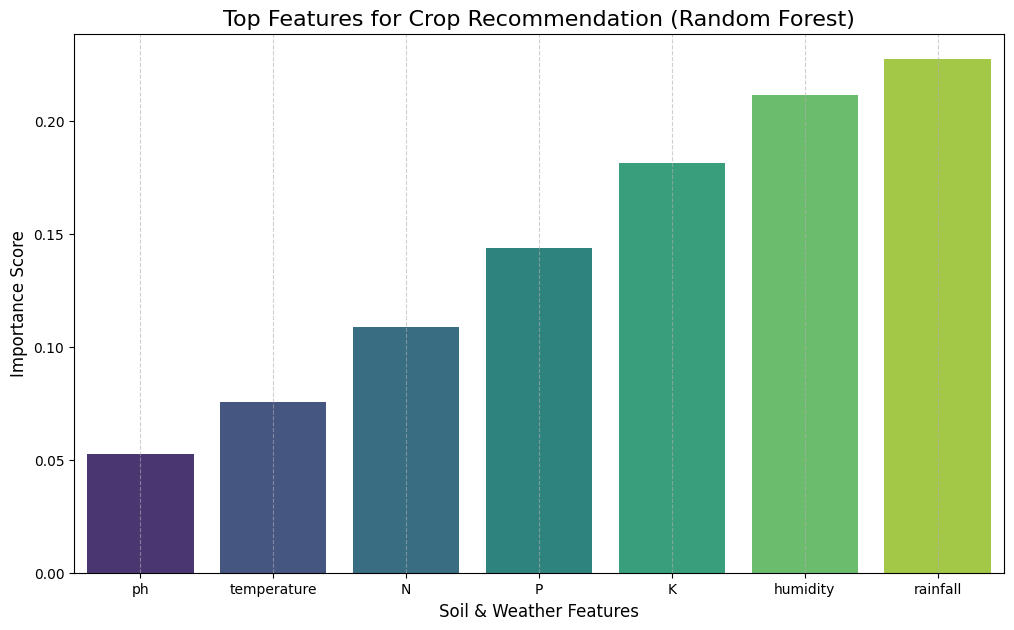

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = x.columns

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True)


plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Importance', data=feature_df, palette='viridis', hue= 'Feature', legend= False)

plt.title('Top Features for Crop Recommendation (Random Forest)', fontsize=16)
plt.ylabel('Importance Score', fontsize=12)
plt.xlabel('Soil & Weather Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Confusion Matrix</p>

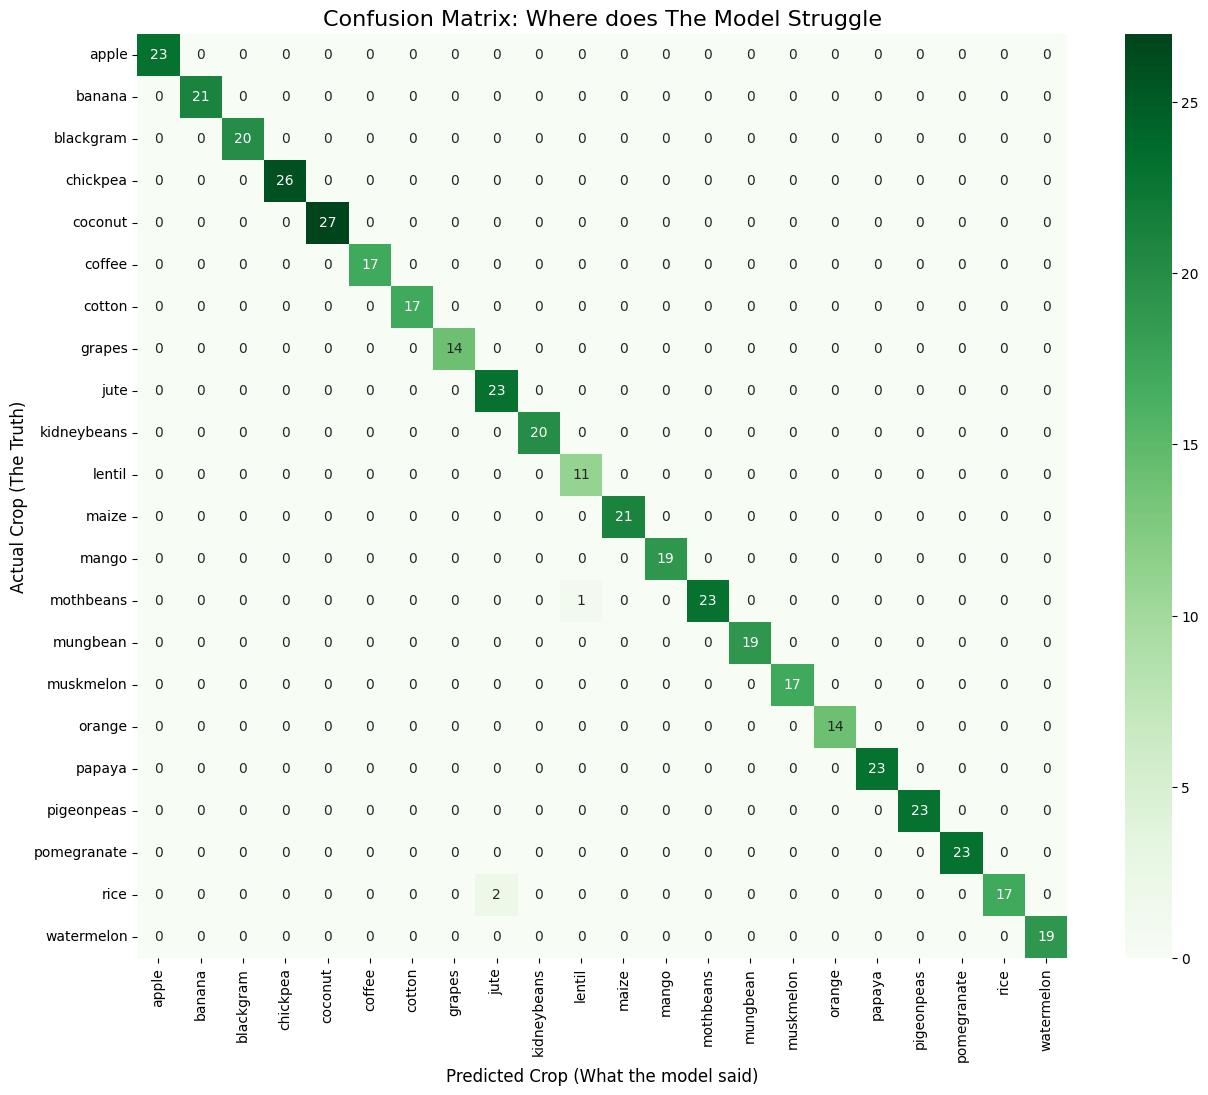

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize= (15, 12))
sns.heatmap(cm, annot= True, fmt='d', cmap='Greens',
           xticklabels= le.classes_, yticklabels= le.classes_, )
plt.title("Confusion Matrix: Where does The Model Struggle", fontsize= 16)
plt.xlabel('Predicted Crop (What the model said)', fontsize=12,)
plt.ylabel('Actual Crop (The Truth)', fontsize=12)
plt.show()

 <a id="1"></a>
# <p style="background-color:#44d180;font-family:roboto;color:#0a0a0b;font-size:150%;text-align:center;border-radius:60px 40px;">Model Deployment & Export</p>

<div style="background-color:#44d180; color:#0a0a0b; font-family:roboto; font-size:100%; text-align:left; border-radius:10px; padding:10px; border-left: 10px solid #2e8b57; width: 50%;">
    <strong>Note:</strong> We are exporting the model and label file using Pickle for future deployment in web or mobile apps.
</div>


In [23]:
import pickle
import os
    
file_path = "C:\\2026 june preparation\\machine learning\\machine learning projects\\crop recommendation"

with open(os.path.join(file_path,'crop_rf_model.pkl'), 'wb') as model_file:
    pickle.dump(rf_model, model_file)

with open(os.path.join(file_path,'Label_rf_model.pkl'), 'wb') as label_file:
    pickle.dump(le, label_file)

<div style="background-color:#44d180; color:#0a0a0b; font-family:roboto; font-size:100%; text-align:left; border-radius:10px; padding:10px; border-left: 10px solid #2e8b57; width: 30%;">
    <strong>Note:</strong> Now import model & label file.
</div>


In [24]:
sample_1 = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]]
sample_2 = [[104, 18, 30, 23.6, 60.3, 6.7, 140.9]]
sample_3 = [[20, 130, 200, 22.0, 90.0, 5.8, 110.0]]  

<div style="background-color:#44d180; color:#0a0a0b; font-family:roboto; font-size:100%; text-align:left; border-radius:10px; padding:10px; border-left: 10px solid #2e8b57; width: 42%;">
    <strong>Note:</strong> Example input: [[N, P, K, temp, hum, ph, rain]]
</div>


In [28]:
model_file_path = "C:\\2026 june preparation\\machine learning\\machine learning projects\\crop recommendation\\crop_rf_model.pkl"
label_file_path = "C:\\2026 june preparation\\machine learning\\machine learning projects\\crop recommendation\\Label_rf_model.pkl"

with open(model_file_path, "rb") as f: 
    rf_model = pickle.load(f)

with open(label_file_path, "rb") as l:
    label_id = pickle.load(l)

result_id = rf_model.predict(sample_1)

print(f"Crop id in label:{result_id}")

crop_name = label_id.inverse_transform(result_id)    

print(f"Crop Name: {crop_name}")

Crop id in label:[20]
Crop Name: ['rice']


C:\Users\bandi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# 🏁 Conclusion & Final Insights

---

### **1. Model Performance Recap**
In this project, we successfully developed a high-precision **Crop Recommendation System**. After evaluating multiple algorithms, the results were as follows:
*   **Logistic Regression:** Provided a solid baseline with **~97%** accuracy.
*   **Decision Tree:** Showed great potential but was prone to slight overfitting.
*   **Random Forest (Winner):** Achieved an outstanding testing accuracy of **99.36%**, proving to be the most robust and reliable model for this dataset.

### **2. Key Findings**
*   **Rainfall** & **Humidity** & **Potassium (K)** levels were identified as the most critical factors in determining the suitable crop.
*   The model demonstrated excellent **Generalization** capabilities, with a minimal gap between training and testing scores.

### **3. Deployment Ready**
The final model and the **LabelEncoder** have been exported as **`.pkl`** files using **Pickle**. This makes the system ready for integration into:
*   **Web Applications** (using Flask or Django).
*   **Mobile Apps** for farmers to get instant recommendations.
*   **IoT Devices** for automated precision farming.

---
**Thank you for exploring this notebook! If you found it helpful, please consider giving it an UPVOTE! 🌟**
